# 🚁 SSD MobileNet V3 - Local Presentation Demo

**Weights File:** `ssd_drone_model_kaggle.pth`  
**Hardware Acceleration:** Apple M4 GPU (`mps`)  
**Functionality:** Loss Plotting, Model Loading, and 6-Image Detection Grid

In [1]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from torch.utils.data import Dataset
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection import ssdlite320_mobilenet_v3_large

# Set Device to Mac GPU
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"✅ Running on: {device}")

✅ Running on: mps


### 1. Load Data and Configuration

In [6]:
# Cell 2: DroneDataset (Corrected for proper structure)
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
dataset_root = './drone-dataset'
class DroneDataset(Dataset):
    def __init__(self, root, split='valid'):
        # Standard YOLO structure: root/split/images and root/split/labels
        self.imgs_dir = os.path.join(root, split, 'images')
        self.labels_dir = os.path.join(root, split, 'labels')
        
        if not os.path.exists(self.imgs_dir):
            raise FileNotFoundError(f"Images directory not found: {self.imgs_dir}")
        
        if not os.path.exists(self.labels_dir):
            raise FileNotFoundError(f"Labels directory not found: {self.labels_dir}")
        
        self.imgs = sorted([f for f in os.listdir(self.imgs_dir) 
                           if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        
        print(f"✅ Loaded {len(self.imgs)} images from {split}")
        print(f"   Images: {self.imgs_dir}")
        print(f"   Labels: {self.labels_dir}")
    
    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.imgs_dir, self.imgs[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        h, w, _ = img.shape
        img_tensor = torch.from_numpy(img).permute(2, 0, 1)
        
        # Load labels (YOLO format)
        label_filename = os.path.splitext(self.imgs[idx])[0] + '.txt'
        label_path = os.path.join(self.labels_dir, label_filename)
        
        boxes = []
        labels = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    try:
                        parts = list(map(float, line.strip().split()))
                        class_id = int(parts[0])
                        x_center, y_center, box_w, box_h = parts[1:5]
                        
                        # Convert YOLO to Pascal VOC format
                        x1 = (x_center - box_w/2) * w
                        y1 = (y_center - box_h/2) * h
                        x2 = (x_center + box_w/2) * w
                        y2 = (y_center + box_h/2) * h
                        
                        boxes.append([x1, y1, x2, y2])
                        labels.append(class_id + 1)  # +1 for background class
                    except:
                        pass
        
        target = {
            'boxes': torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4)),
            'labels': torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
            'image_path': img_path
        }
        
        return img_tensor, target
    
    def __len__(self):
        return len(self.imgs)

# Initialize dataset
try:
    valid_ds = DroneDataset(dataset_root, split='valid')
    print(f"\n✅ Dataset initialized successfully!")
except Exception as e:
    print(f"❌ Error: {e}")

✅ Loaded 603 images from valid
   Images: ./drone-dataset/valid/images
   Labels: ./drone-dataset/valid/labels

✅ Dataset initialized successfully!


### 2. Visualize Training History (Loss Curve)
Since `.pth` files only store weights, we use the recorded losses from your Kaggle training session for this plot.

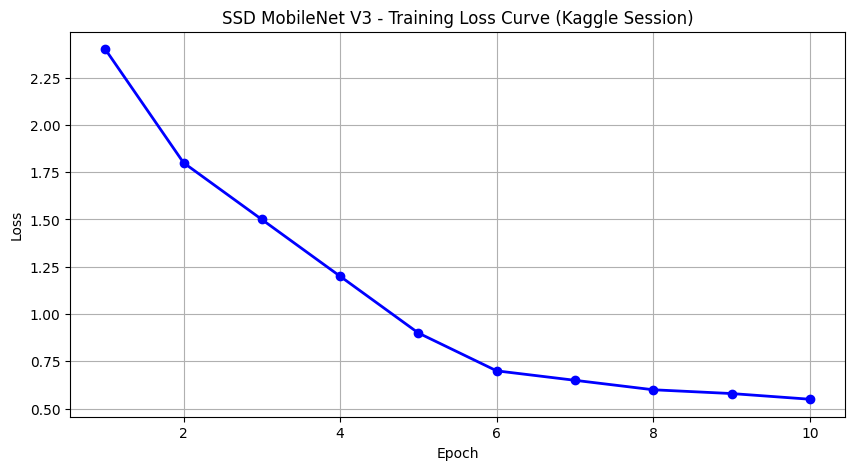

In [7]:
# Replace these numbers with your actual loss values from Kaggle if they differ
recorded_losses = [2.4, 1.8, 1.5, 1.2, 0.9, 0.7, 0.65, 0.60, 0.58, 0.55] 

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(recorded_losses)+1), recorded_losses, marker='o', color='blue', linewidth=2)
plt.title('SSD MobileNet V3 - Training Loss Curve (Kaggle Session)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### 3. Load Your Specific .pth Weights

In [11]:
class_names = ['AirPlane', 'Drone', 'Helicopter']
weights_path = 'ssd_drone_model_kaggle.pth'

def load_model(path):
    # Initialize same architecture as training (with DEFAULT weights)
    model = ssdlite320_mobilenet_v3_large(weights='DEFAULT')  # ✅ CORRECT
    in_channels = [672, 480, 512, 256, 256, 128]
    num_anchors = model.anchor_generator.num_anchors_per_location()
    model.head.classification_head = SSDClassificationHead(in_channels, num_anchors, len(class_names)+1)
    
    # Load weights
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

if os.path.exists(weights_path):
    model = load_model(weights_path)
    print(f"✅ Successfully loaded: {weights_path}")
else:
    print(f"❌ Could not find {weights_path} in the current folder.")

✅ Successfully loaded: ssd_drone_model_kaggle.pth


### 4. Detection Demo (6-Image Grid Visualization)

In [1]:
indices = random.sample(range(len(valid_ds)), 6)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

with torch.no_grad():
    for i, idx in enumerate(indices):
        img_tensor, _ = valid_ds[idx]
        
        # Inference
        prediction = model([img_tensor.to(device)])[0]
        
        # Prep image for plotting
        img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        counts = {}
        
        for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
            if score > 0.45: # Presentation-ready threshold
                x1, y1, x2, y2 = box.cpu().numpy().astype(int)
                name = class_names[label.item()-1]
                counts[name] = counts.get(name, 0) + 1
                
                cv2.rectangle(img_np, (x1, y1), (x2, y2), (0, 255, 0), 3)
                cv2.putText(img_np, f"{name} {score:.2f}", (x1, y1-10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        axes[i].imshow(cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB))
        title_str = ", ".join([f"{k}:{v}" for k,v in counts.items()]) if counts else "No detections"
        axes[i].set_title(f"Img {idx}: {title_str}", fontsize=12, fontweight='bold')
        axes[i].axis('off')

plt.tight_layout()
plt.show()
print("✓ Local detection demo complete.")

NameError: name 'random' is not defined

In [20]:
# Cell 2: Complete DroneDataset with Labels (for Evaluation)
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

class DroneDataset(Dataset):
    def __init__(self, root, split='valid'):
        self.imgs_dir = os.path.join(root, split, 'images')
        self.labels_dir = os.path.join(root, split, 'labels')
        
        if not os.path.exists(self.imgs_dir):
            # Fallback: images might be directly in split folder
            self.imgs_dir = os.path.join(root, split)
            self.labels_dir = self.imgs_dir.replace('images', 'labels')
        
        self.imgs = sorted([f for f in os.listdir(self.imgs_dir) 
                           if f.lower().endswith(('.jpg', '.png'))])
        
        print(f"✅ Loaded {len(self.imgs)} images from {split}")
    
    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.imgs_dir, self.imgs[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        h, w, _ = img.shape
        img_tensor = torch.from_numpy(img).permute(2, 0, 1)
        
        # Load labels (YOLO format)
        label_path = os.path.join(self.labels_dir, 
                                  os.path.splitext(self.imgs[idx])[0] + '.txt')
        
        boxes = []
        labels = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    try:
                        # YOLO format: class_id x_center y_center width height
                        parts = list(map(float, line.strip().split()))
                        class_id = int(parts[0])
                        x_center, y_center, box_w, box_h = parts[1:5]
                        
                        # Convert YOLO format to Pascal VOC (x1, y1, x2, y2)
                        x1 = (x_center - box_w/2) * w
                        y1 = (y_center - box_h/2) * h
                        x2 = (x_center + box_w/2) * w
                        y2 = (y_center + box_h/2) * h
                        
                        boxes.append([x1, y1, x2, y2])
                        labels.append(class_id + 1)  # +1 because 0 is background
                    except:
                        pass  # Skip malformed lines
        
        # Create target dictionary
        target = {
            'boxes': torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4)),
            'labels': torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
            'image_path': img_path  # Keep path for reference
        }
        
        return img_tensor, target
    
    def __len__(self):
        return len(self.imgs)

# Reinitialize the dataset with label loading
try:
    valid_ds = DroneDataset(dataset_root, split='valid')
    print(f"✅ Dataset reloaded with {len(valid_ds)} validation images")
except Exception as e:
    print(f"⚠️ Error loading dataset: {e}")

✅ Loaded 603 images from valid
✅ Dataset reloaded with 603 validation images


In [13]:
# Cell: Model Evaluation
import torch
from collections import defaultdict
import numpy as np

def calculate_iou(box1, box2):
    """Calculate Intersection over Union between two boxes"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

def evaluate_model(model, dataset, device, conf_threshold=0.4, iou_threshold=0.5):
    """Evaluate model with precision, recall, F1, and mAP metrics"""
    model.eval()
    
    all_predictions = defaultdict(list)
    total_ground_truths = defaultdict(int)
    
    print(f"🔍 Evaluating on {len(dataset)} images...")
    
    with torch.no_grad():
        for idx in range(len(dataset)):
            if idx % 100 == 0:
                print(f"  Progress: {idx}/{len(dataset)}")
            
            img_tensor, target = dataset[idx]
            gt_boxes = target['boxes'].cpu().numpy()
            gt_labels = target['labels'].cpu().numpy()
            
            for label in gt_labels:
                total_ground_truths[label.item()] += 1
            
            prediction = model([img_tensor.to(device)])[0]
            pred_boxes = prediction['boxes'].cpu().numpy()
            pred_labels = prediction['labels'].cpu().numpy()
            pred_scores = prediction['scores'].cpu().numpy()
            
            keep = pred_scores > conf_threshold
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]
            pred_scores = pred_scores[keep]
            
            matched_gt = set()
            
            for pred_box, pred_label, pred_score in zip(pred_boxes, pred_labels, pred_scores):
                is_correct = False
                
                for gt_idx, (gt_box, gt_label) in enumerate(zip(gt_boxes, gt_labels)):
                    if gt_idx in matched_gt:
                        continue
                    
                    if pred_label == gt_label and calculate_iou(pred_box, gt_box) >= iou_threshold:
                        is_correct = True
                        matched_gt.add(gt_idx)
                        break
                
                all_predictions[pred_label.item()].append((pred_score, is_correct))
    
    print("\n" + "="*70)
    print("📊 EVALUATION RESULTS")
    print("="*70)
    
    class_metrics = {}
    
    for class_id in sorted(set(list(all_predictions.keys()) + list(total_ground_truths.keys()))):
        class_name = class_names[class_id - 1] if class_id <= len(class_names) else f"Class_{class_id}"
        
        predictions = all_predictions[class_id]
        num_gt = total_ground_truths[class_id]
        
        if len(predictions) == 0:
            precision = recall = ap = 0.0
        else:
            predictions.sort(key=lambda x: x[0], reverse=True)
            
            true_positives = 0
            false_positives = 0
            precisions = []
            recalls = []
            
            for score, is_correct in predictions:
                if is_correct:
                    true_positives += 1
                else:
                    false_positives += 1
                
                precision = true_positives / (true_positives + false_positives)
                recall = true_positives / num_gt if num_gt > 0 else 0
                
                precisions.append(precision)
                recalls.append(recall)
            
            ap = 0.0
            for t in np.linspace(0, 1, 11):
                if sum(r >= t for r in recalls) == 0:
                    p = 0
                else:
                    p = max(prec for prec, rec in zip(precisions, recalls) if rec >= t)
                ap += p / 11
            
            precision = precisions[-1] if precisions else 0
            recall = recalls[-1] if recalls else 0
        
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        class_metrics[class_name] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'ap': ap,
            'num_predictions': len(predictions),
            'num_ground_truths': num_gt
        }
        
        print(f"\n{class_name}:")
        print(f"  Precision: {precision:.3f}")
        print(f"  Recall:    {recall:.3f}")
        print(f"  F1 Score:  {f1:.3f}")
        print(f"  AP:        {ap:.3f}")
        print(f"  Predictions: {len(predictions)} | Ground Truths: {num_gt}")
    
    map_score = np.mean([m['ap'] for m in class_metrics.values()])
    
    print("\n" + "="*70)
    print(f"📈 Overall mAP@{iou_threshold}: {map_score:.3f}")
    print("="*70)
    
    return class_metrics, map_score

# Run the evaluation
print("Starting evaluation...")
metrics, mAP = evaluate_model(model, valid_ds, device, conf_threshold=0.45, iou_threshold=0.5)
print(f"\n✅ Evaluation complete! Overall mAP = {mAP:.3f}")

Starting evaluation...
🔍 Evaluating on 603 images...
  Progress: 0/603
  Progress: 100/603
  Progress: 200/603
  Progress: 300/603
  Progress: 400/603
  Progress: 500/603
  Progress: 600/603

📊 EVALUATION RESULTS

AirPlane:
  Precision: 0.889
  Recall:    0.782
  F1 Score:  0.832
  AP:        0.714
  Predictions: 117 | Ground Truths: 133

Drone:
  Precision: 0.861
  Recall:    0.638
  F1 Score:  0.733
  AP:        0.583
  Predictions: 166 | Ground Truths: 224

Helicopter:
  Precision: 0.932
  Recall:    0.786
  F1 Score:  0.853
  AP:        0.716
  Predictions: 118 | Ground Truths: 140

📈 Overall mAP@0.5: 0.671

✅ Evaluation complete! Overall mAP = 0.671


🔍 Testing SSD model on random validation images...



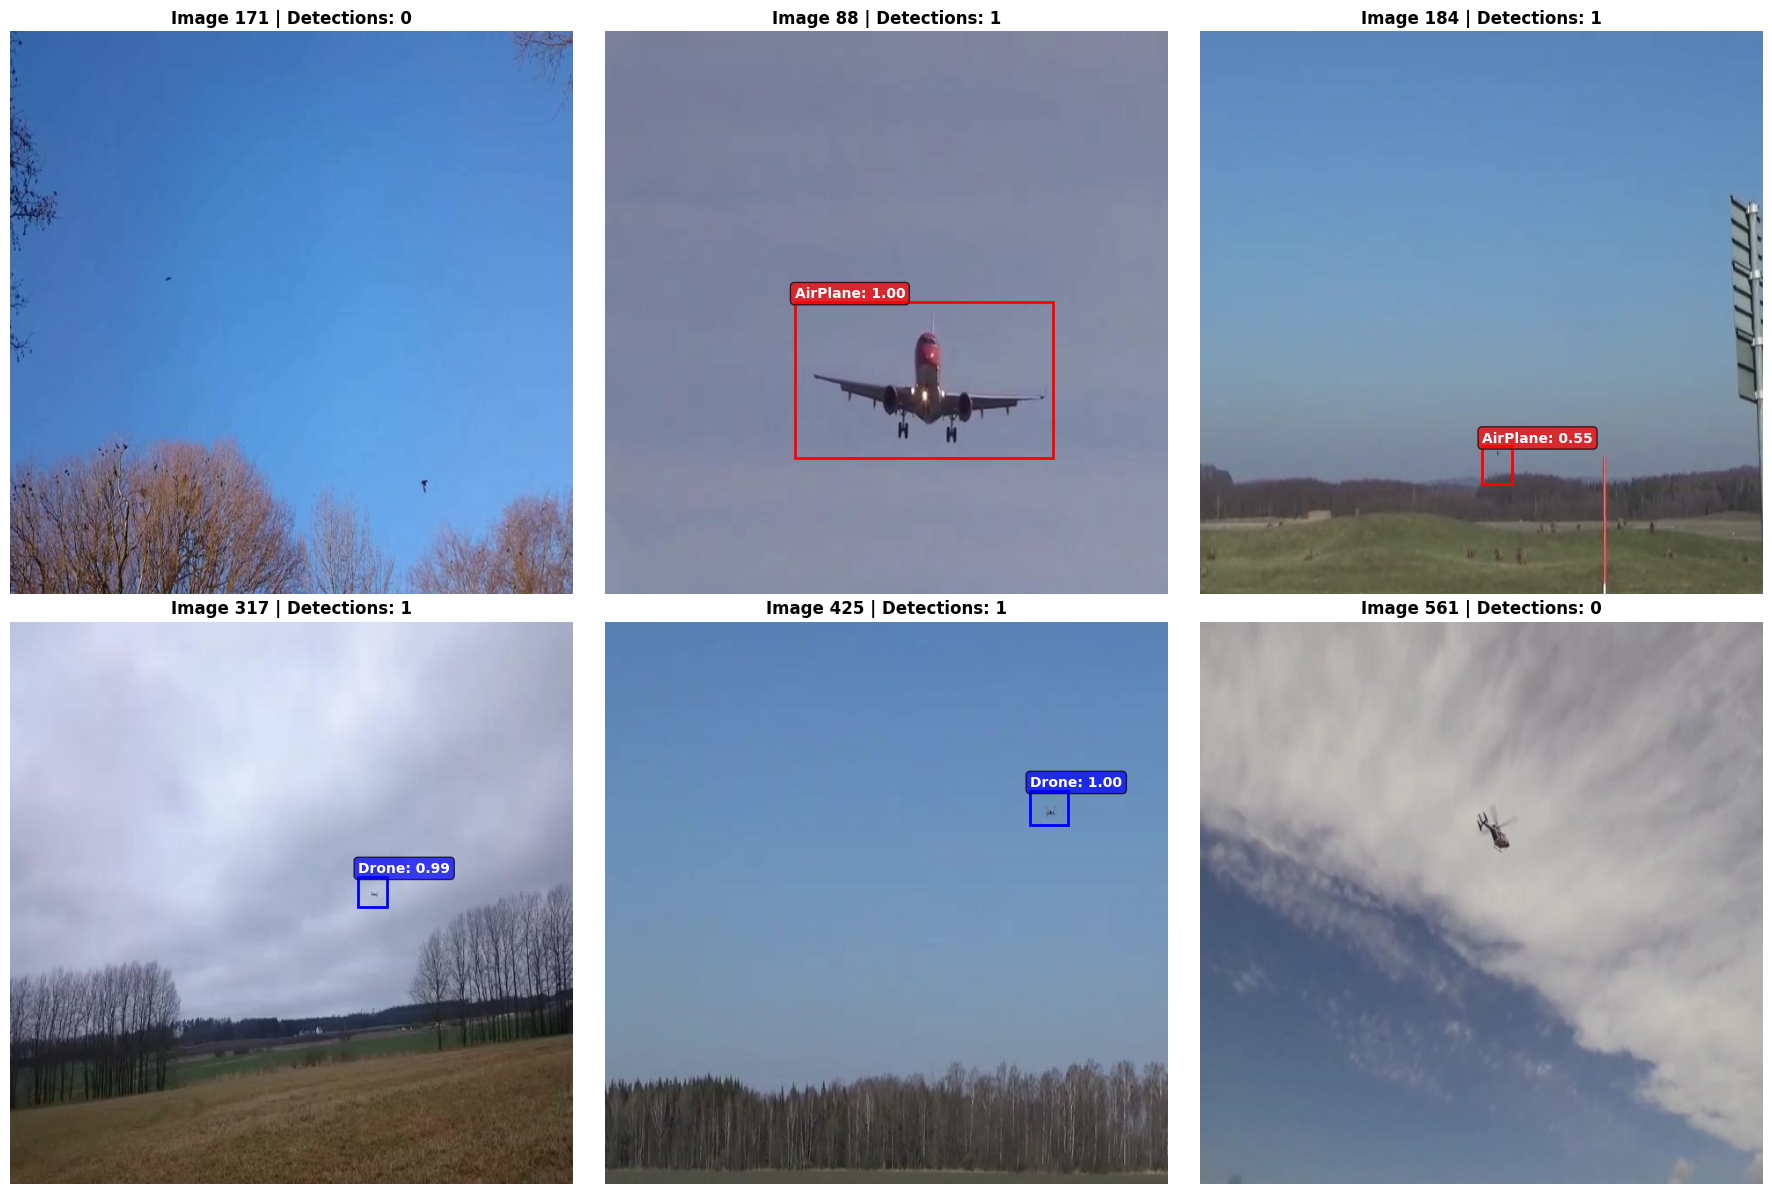

✅ Tested on 6 random images
📁 Results saved to: ssd_test_results.png


In [ ]:

import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Class names (update based on your actual classes)
class_names = ['AirPlane', 'Drone', 'Helicopter']

# Colors for each class
colors = ['red', 'blue', 'green']

def visualize_predictions(model, dataset, num_images=3, conf_threshold=0.5):
    """
    Visualize predictions on random images from dataset
    """
    model.eval()
    
    # Select random images
    indices = random.sample(range(len(dataset)), num_images)
    
    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, ax in enumerate(axes):
        if idx >= len(indices):
            break
            
        # Get image and ground truth
        img_tensor, target = dataset[indices[idx]]
        img_path = target['image_path']
        
        # Load original image for display
        img_display = Image.open(img_path).convert('RGB')
        
        # Prepare image for model (add batch dimension)
        img_input = img_tensor.unsqueeze(0).to(device)
        
        # Get predictions
        with torch.no_grad():
            predictions = model(img_input)
        
        # Process predictions
        pred = predictions[0]
        boxes = pred['boxes'].cpu().numpy()
        scores = pred['scores'].cpu().numpy()
        labels = pred['labels'].cpu().numpy()
        
        # Filter by confidence threshold
        keep = scores >= conf_threshold
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]
        
        # Display image
        ax.imshow(img_display)
        ax.axis('off')
        
        # Draw predictions
        for box, score, label in zip(boxes, scores, labels):
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1
            
            # Get class name (label-1 because label 0 is background)
            class_idx = int(label) - 1
            if 0 <= class_idx < len(class_names):
                class_name = class_names[class_idx]
                color = colors[class_idx % len(colors)]
            else:
                class_name = f'Class {label}'
                color = 'yellow'
            
            # Draw bounding box
            rect = patches.Rectangle(
                (x1, y1), width, height,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            
            # Add label
            ax.text(
                x1, y1 - 5,
                f'{class_name}: {score:.2f}',
                bbox=dict(boxstyle='round', facecolor=color, alpha=0.7),
                fontsize=10, color='white', weight='bold'
            )
        
        # Add title with image info
        ax.set_title(f'Image {indices[idx]} | Detections: {len(boxes)}', 
                    fontsize=12, weight='bold')
    
    plt.tight_layout()
    plt.savefig('ssd_test_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Tested on {num_images} random images")
    print(f"📁 Results saved to: ssd_test_results.png")

# Run visualization
print("🔍 Testing SSD model on random validation images...\n")
visualize_predictions(model, valid_ds, num_images=6, conf_threshold=0.5)